In [ ]:
from autoreduce import *
import numpy as np

Classic SIR model is too simple, so I decided to go with the SEIR model (commonly used for COVID)

$
\dot{x} = f(x,\Theta) \\
y = Cx \\
x =
\begin{bmatrix}
S \\
E \\
I \\
R
\end{bmatrix}
\\
\Theta =
\begin{bmatrix}
\beta \\
\sigma \\
\gamma \\
N
\end{bmatrix}
\\
y = I
$

S = Susceptible, E - Exposed, I = Infected, R = Recovered; SEIR ODE system

$
\begin{aligned}
\dot{S} &= -\frac{\beta S I}{N} \\
\dot{E} &= \frac{\beta S I}{N} - \sigma E \\
\dot{I} &= \sigma E - \gamma I \\
\dot{R} &= \gamma I
\end{aligned}
$

In [ ]:
from autoreduce import *
import numpy as np
import matplotlib.pyplot as plt

# SEIR population model
n = 4
nouts = 1

# States:
# x[0] = S, Susceptible
# x[1] = E, Exposed
# x[2] = I, Infected
# x[3] = R, Recovered

# Parameters:
# P[0] = beta   infection/transmission rate
# P[1] = sigma  exposed -> infected rate
# P[2] = gamma  recovery rate
# P[3] = N      total population

P = np.zeros(4)

P[0] = 0.35     # beta
P[1] = 0.20     # sigma
P[2] = 0.10     # gamma
P[3] = 1000     # N

params_values = P.copy()
timepoints_ode = np.linspace(0, 150, 100)

x_init = np.zeros(n)
x_init[0] = 990   # S
x_init[1] = 9     # E
x_init[2] = 1     # I
x_init[3] = 0     # R

error_tol = 100
nstates_tol = 2

x, f, P = load_ODE_model(n, len(params_values))
params = P

# SEIR ODEs
f[0] = -P[0] * x[0] * x[2] / P[3]

f[1] = P[0] * x[0] * x[2] / P[3] - P[1] * x[1]

f[2] = P[1] * x[1] - P[2] * x[2]

f[3] = P[2] * x[2]

# Output: infected population I
C = np.zeros((nouts, len(x)), dtype=int)
C[0][2] = 1
C = C.tolist()

sys = System(
    x,
    f,
    params=params,
    C=C,
    params_values=params_values,
    x_init=x_init
)

Main thing that changed is that the varaible/out is x[2], which is the infected popuation.

In [7]:
sys.x

[x0, x1, x2, x3]

In [8]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')

Plotting libraries missing.


In [9]:
from autoreduce.utils import get_reducible
timepoints_ssm = np.linspace(0,60,10)
timepoints_ode = np.linspace(0, 100, 100)
sys_reduce = get_reducible(sys, timepoints_ode, timepoints_ssm)
#results = sys_reduce.reduce_simple(skip_numerical_computation = True,skip_error_computation = True, skip_robustness_computation = True)
results = sys_reduce.reduce_simple()

Could not find solution for: x3 from P2*x2
Successful solution obtained with states: [x2]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x3 from P2*x2
Successful solution obtained with states: [x0, x2]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x3 from P2*x2
Successful solution obtained with states: [x1, x2]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Successful solution obtained with states: [x2, x3]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Suc

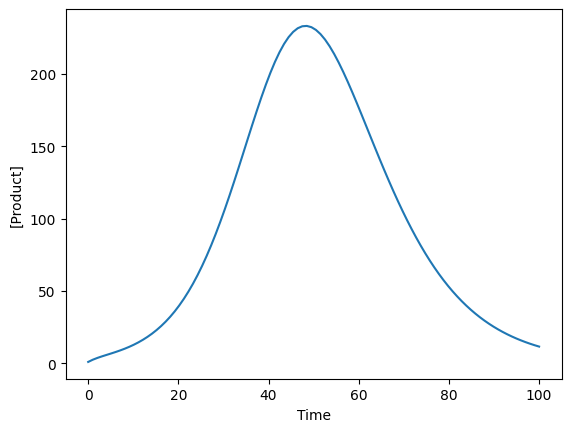

In [10]:
from autoreduce.utils import get_ODE
sys_ode = get_ODE(sys, timepoints_ode)
sol = sys_ode.solve_system().T
#try:
import matplotlib.pyplot as plt
plt.plot(timepoints_ode, np.transpose(np.array(C)@sol))
plt.xlabel('Time')
plt.ylabel('[Product]')
plt.show()